# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [24]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#647cb8">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #cb9255; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#cb9255">**выборы**</font> и подбирать <font color="#cb9255">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [25]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import pandas as pd
import os
from os.path import getsize

matches_df_train = pd.read_csv('matches_df_train.csv')
matches_df_test = pd.read_csv('matches_df_test.csv')
path1 = 'matches_df_train.csv'
path2 = 'matches_df_test.csv'
#вот эта штука инфо только для коллонок по содержанию, для памяти отдельно две ячейки сделала
print(f" Колонки: {matches_df_train.info()}")
print(f"Размер {matches_df_train.shape}")
print('\n')
print(f" Колонки: {matches_df_test.info()}")
print(f"Размер {matches_df_test.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641090 entries, 0 to 641089
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   match_id     641090 non-null  int64  
 1   date         641090 non-null  object 
 2   region       641090 non-null  object 
 3   game_mode    641090 non-null  int64  
 4   duration     641090 non-null  int64  
 5   radiant_win  641090 non-null  bool   
 6   avg_mmr      472334 non-null  float64
dtypes: bool(1), float64(1), int64(3), object(2)
memory usage: 30.0+ MB
 Колонки: None
Размер (641090, 7)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   match_id   59748 non-null  int64  
 1   date       59748 non-null  object 
 2   region     59748 non-null  object 
 3   game_mode  59748 non-null  int64  
 4   avg_mmr    44504 non-null  float64
dtypes:

In [26]:
!du -h matches_df_train.csv

 29M	matches_df_train.csv


In [27]:
!du -h matches_df_test.csv

2.1M	matches_df_test.csv


Мы видим, что в тесте нет duration, поэтому удаляем его на трейне

In [28]:
matches_df_train.drop('duration', axis=1, inplace=True)

Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

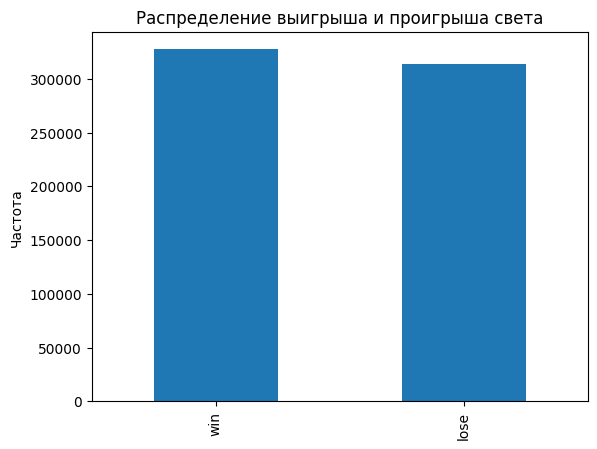

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

winorlose_df = matches_df_train['radiant_win'].value_counts()
winorlose_df.index = ['win','lose']
winorlose_df.plot(kind='bar')
plt.title('Распределение выигрыша и проигрыша света')
plt.ylabel('Частота')
plt.show()


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** Как написано в лекции, Джини позволяет увеличить относительную разницу, плюс к тому хорошо работает при сбалансированных классах, то есть когда их отношение примерно одинаковое, тк это по сути тот же рок-аук в другой формуле, а рок-аук применим, когда нету сильного отличия в размерах классов
</div> 

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

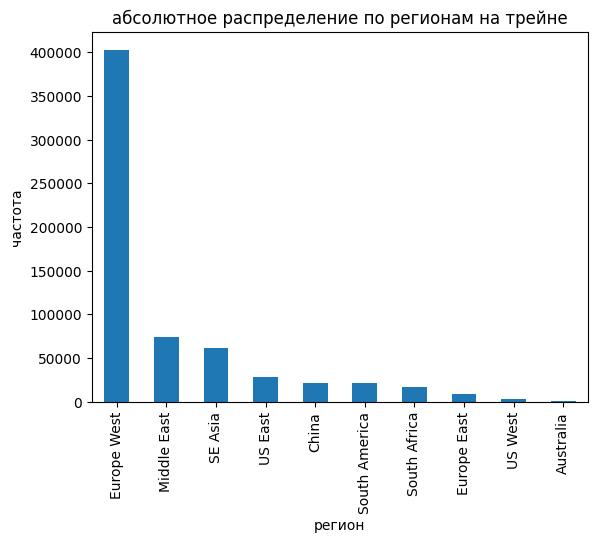

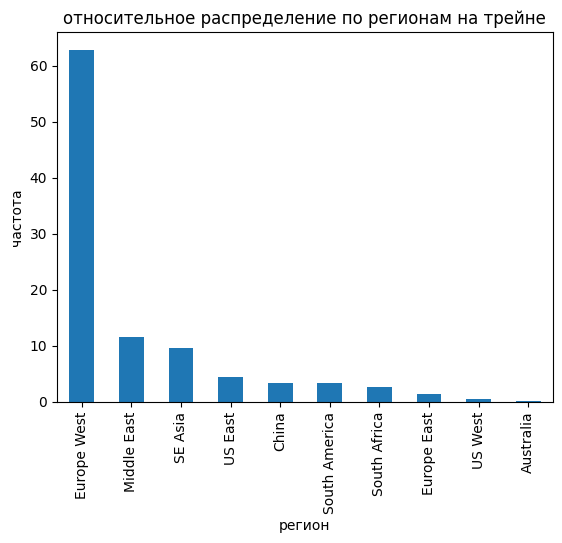

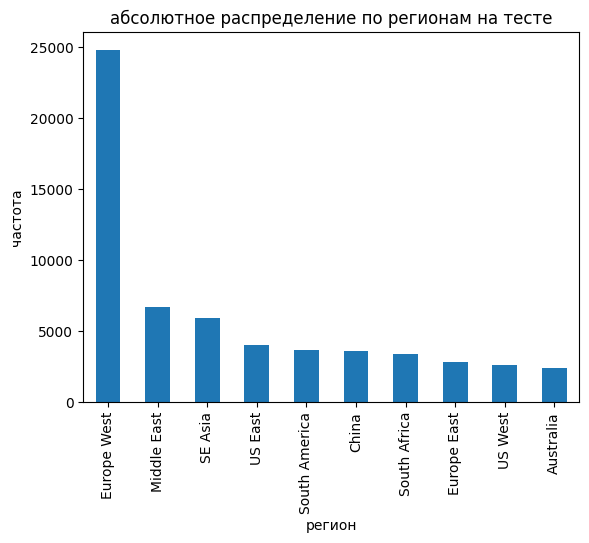

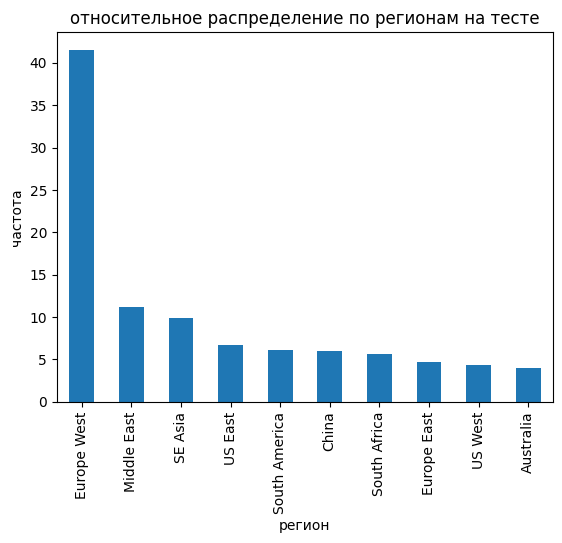

In [30]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
region_df = matches_df_train['region'].value_counts()
region_df.plot(kind='bar')
plt.title('абсолютное распределение по регионам на трейне')
plt.ylabel('частота')
plt.xlabel('регион')
plt.show()


region_df = matches_df_train['region'].value_counts(normalize=True) * 100
region_df.plot(kind='bar')
plt.title('относительное распределение по регионам на трейне')
plt.ylabel('частота')
plt.xlabel('регион')
plt.show()


region_df = matches_df_test['region'].value_counts()
region_df.plot(kind='bar')
plt.title('абсолютное распределение по регионам на тесте')
plt.ylabel('частота')
plt.xlabel('регион')
plt.show()


region_df = matches_df_test['region'].value_counts(normalize=True) * 100
region_df.plot(kind='bar')
plt.title('относительное распределение по регионам на тесте')
plt.ylabel('частота')
plt.xlabel('регион')
plt.show()

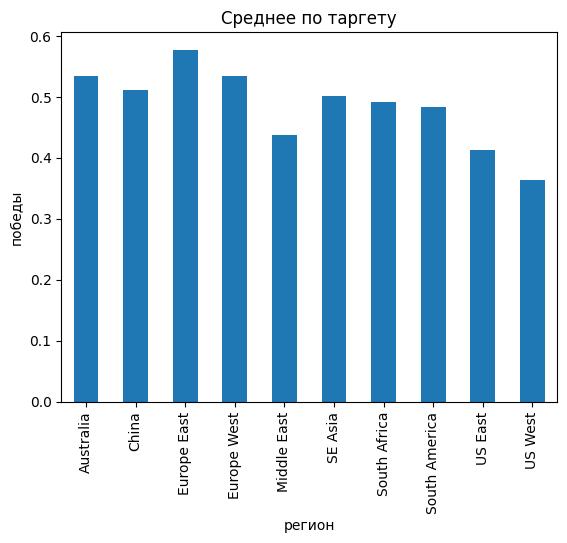

In [31]:
dist = matches_df_train.groupby('region')['radiant_win'].mean()
dist.plot(kind='bar')
plt.title('Среднее по таргету')
plt.ylabel('победы')
plt.xlabel('регион')
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**  Распределение на трейне и на тесте в относительных величинах достаточно схожи, поэтому можно обучать, к тому же как выяснили выше, пропусков по регионам у нас нет.(в табличке от инфо есть). Сигнал наверное есть, потому что достаточно выраженно можем отделить западную европу от других.
</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 

</div>

In [32]:
!pip install -qU category-encoders

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** Мне тут кажется ОНЕ наиболее няшным, потому что у нас всего 10 регионов, то есть всего 9 новых колонок(10 колонок образуют мультиколинеарность это вроде не очень хорошо), плюс к тому среднее значение у нас варьируется от 0 до 1 и я не ручаюсь за надежность float в питоне, потому что у нас есть близкие значения, чтобы не произрошло неожидланного округления и один регион не исчез просто.
</div>

Закодируйте колонку `region` выбранным вами способом

In [33]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import category_encoders as ce

onehotencoder = ce.OneHotEncoder(cols=['region'],use_cat_names=True)
matches_df_train = onehotencoder.fit_transform(matches_df_train)
matches_df_test = onehotencoder.fit_transform(matches_df_test)


Использовала <br>
* https://contrib.scikit-learn.org/category_encoders/ 
* https://contrib.scikit-learn.org/category_encoders/onehot.html

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

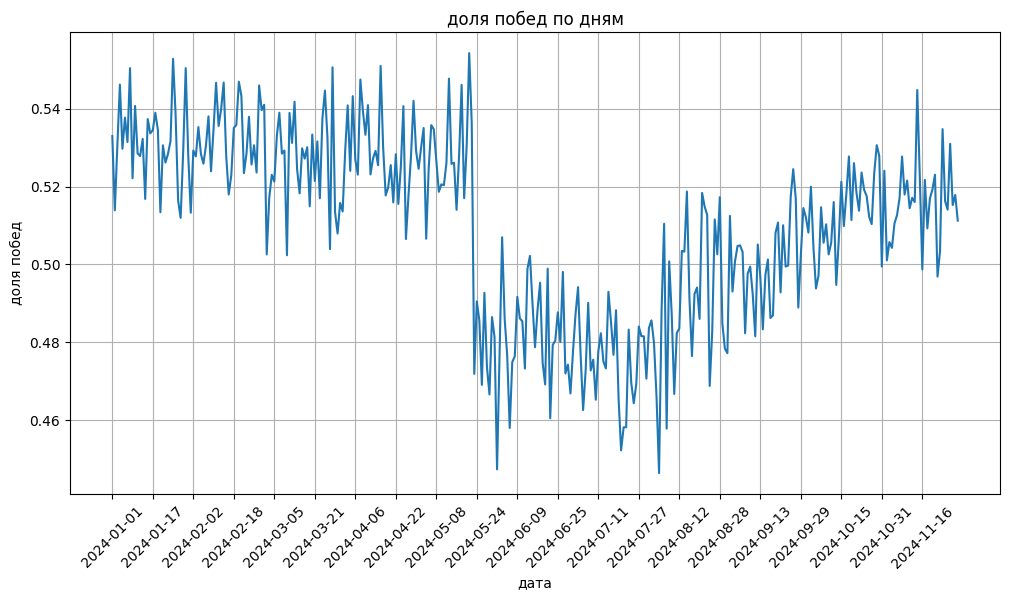

In [34]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
date_match = matches_df_train.groupby('date')['radiant_win'].mean().reset_index(name='proportion')

plt.figure(figsize=(12, 6))
plt.plot(date_match['date'], date_match['proportion'])
plt.title('доля побед по дням')
plt.xlabel('дата')
plt.ylabel('доля побед')
plt.xticks(date_match['date'][::len(date_match)//20], rotation=45)
plt.grid()
plt.show()


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** будет грустно если кто-то найдет мой запрос в гугл  "когда обновлялась дота". так, она обновилась  24 мая, что соотвесвтует скачку вниз на нашем графике, что значит, что пользователям - игрокам светлой стороны играть с обновлением становится тяжелее, плюс какие-то фиксы, которые вносятся раз в две недели или месяц. Также наблюдаемо, что есть как бы локальные колебания графика, это связано с небольшим изменениям техник, предметов и проч. Итого, получается до последнего апдейта превалирует все-таки победа светлой стороны, потом это фиксят и светлые снова начинают чаще побеждать, просто из-за адаптации.

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** В общем, сначала я не хотела брать никакие временные фичи, но потом увидела, что задание это все-таки подразумевает, подумала над парочкой гипотез построила графики ниже для того, чтобы не выбирать наобум, первое, что пришло мне на ум - это лето и не лето конкретно июнь/июль и остальное, это я уже выяснила потом, потому что летом в основном все-таки хочется отдыхать, гулять, тусить на море, а не сидеть в душном помещении и играть в комплюктер, а зимой/осенью больше стимулов посидеть дома и порубиться по сетке во что-то крутое.
Вторая гипотеза это о том, что по выходным людям хочется расслабиться поиграть в компутер, но нет, оказалось наоборот и разница не сильно большая, получается киберспортсмены уравновешиваются обычными людьми, которые играют по выходным, когда спортсмены отдыхают. 
Возможно где-то я графики поудаляла, но в общем по времени не очень что-то зависит. Хотелось бы часы возможно посмотреть, потому что некоторые близкие по часовому поясу регионы играют вместе и одерживают победы это может как-то круто коррелировать, но у нас часов нету, поэтому не судьба.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [35]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
matches_df_train['date'] = pd.to_datetime(matches_df_train['date'])
matches_df_test['date'] = pd.to_datetime(matches_df_test['date'])

matches_df_train['day'] = matches_df_train['date'].dt.day
matches_df_train['dayofweek'] = matches_df_train['date'].dt.dayofweek
matches_df_train['month'] = matches_df_train['date'].dt.month
matches_df_train['summer'] = ((matches_df_train['month'] == 6) | (matches_df_train['month'] == 7))


matches_df_test['day'] = matches_df_test['date'].dt.day
matches_df_test['dayofweek'] = matches_df_test['date'].dt.dayofweek
matches_df_test['month'] = matches_df_test['date'].dt.month
matches_df_test['summer'] = ((matches_df_test['month'] == 6) | (matches_df_test['month'] == 7))

matches_df_train

,match_id,date,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,region_Australia,game_mode,radiant_win,avg_mmr,day,dayofweek,month,summer
0,1,2024-02-12,1,0,0,0,0,0,0,0,0,0,4,False,3519.7,12,0,2,False
1,2,2024-04-08,0,1,0,0,0,0,0,0,0,0,2,True,2330.9,8,0,4,False
2,3,2024-06-16,0,0,1,0,0,0,0,0,0,0,1,True,1579.6,16,6,6,True
3,4,2024-09-16,0,0,0,1,0,0,0,0,0,0,22,False,NaN,16,0,9,False
4,5,2024-03-31,0,1,0,0,0,0,0,0,0,0,22,True,NaN,31,6,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641085,767815,2024-07-13,0,0,0,0,1,0,0,0,0,0,1,False,401.1,13,5,7,True
641086,767817,2024-02-02,0,0,0,0,0,0,0,1,0,0,1,False,NaN,2,4,2,False
641087,767818,2024-07-03,0,0,0,0,0,0,0,1,0,0,2,False,1953.4,3,2,7,True
641088,767820,2024-11-08,0,0,0,1,0,0,0,0,0,0,1,True,NaN,8,4,11,False


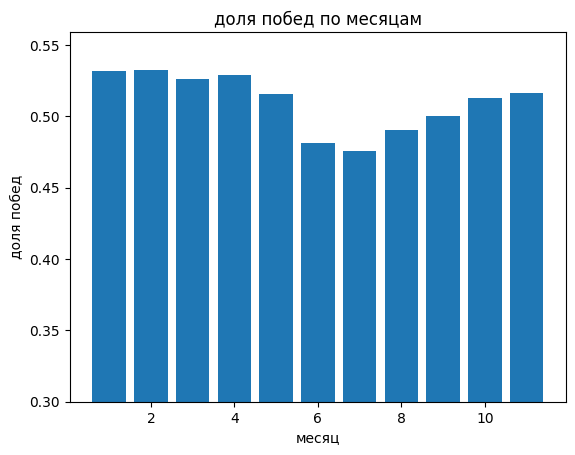

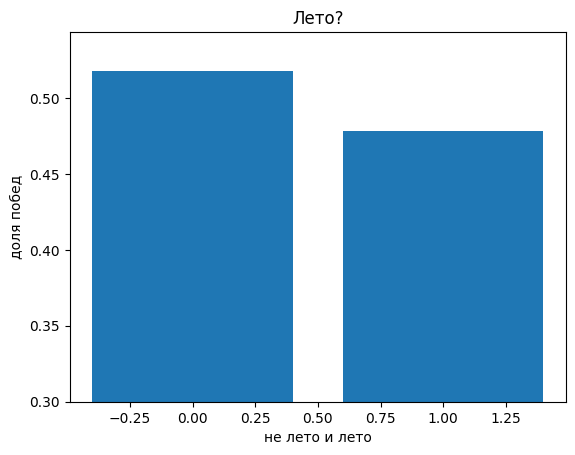

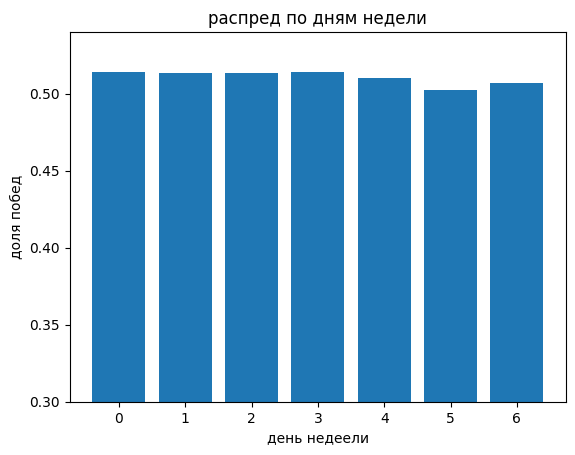

In [36]:
check_month = matches_df_train.groupby('month')['radiant_win'].mean().reset_index(name='proportion')
plt.bar(check_month['month'], check_month['proportion'])
plt.title('доля побед по месяцам')
plt.xlabel('месяц')
plt.ylabel('доля побед')
plt.ylim(ymin=0.3)
plt.show()

check_month = matches_df_train.groupby('summer')['radiant_win'].mean().reset_index(name='proportion')
plt.bar(check_month['summer'], check_month['proportion'])
plt.title('Лето?')
plt.xlabel('не лето и лето')
plt.ylabel('доля побед')
plt.ylim(ymin=0.3)
plt.show()

check_month = matches_df_train.groupby('dayofweek')['radiant_win'].mean().reset_index(name='proportion')
plt.bar(check_month['dayofweek'], check_month['proportion'])
plt.title('распред по дням недели')
plt.xlabel('день недеели')
plt.ylabel('доля побед')
plt.ylim(ymin=0.3)
plt.show()



Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** потому что нам нужно как бы взять границу о времени и разобрать что было и что как бы будет, если будем брать рандомно у нас в одном классе может затесаться будущий месяц, а у нас должно быть по порядку: трейн, валид, тест

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [37]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import sklearn

matches_df_train = matches_df_train.sort_values('date')
crossval = sklearn.model_selection.TimeSeriesSplit(n_splits=4)


если что на будущее и сейчас инфу брала здесь https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html


И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [38]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from sklearn.linear_model import LogisticRegression


date = ['day', 'dayofweek', 'summer']
region = ['region_Europe West',	'region_South Africa',	'region_SE Asia',	'region_Middle East',	'region_US East',	'region_Europe East',	'region_South America',	'region_China',	'region_US West']
date_reg = ['day', 'dayofweek', 'summer', 'region_Europe West',	'region_South Africa',	'region_SE Asia',	'region_Middle East',	'region_US East',	'region_Europe East',	'region_South America',	'region_China',	'region_US West']
y = matches_df_train['radiant_win']
X_date = matches_df_train[date]
X_reg = matches_df_train[region]
X_dr= matches_df_train[date_reg]
fold_scores_date = []
fold_scores_reg = []
fold_scores_dr = []

for i, (train_index, val_index) in enumerate(crossval.split(X_date)):
    X_train, X_val = X_date.iloc[train_index], X_date.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    model = LogisticRegression()
    clf = model.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_val)[:, 1]
    fold_scores_date.append(gini(y_val, y_pred))
print(*fold_scores_date)

for i, (train_index, val_index) in enumerate(crossval.split(X_date)):
    X_train, X_val = X_reg.iloc[train_index], X_reg.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    model = LogisticRegression()
    clf = model.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_val)[:, 1]
    fold_scores_reg.append(gini(y_val, y_pred))
print(*fold_scores_reg)

for i, (train_index, val_index) in enumerate(crossval.split(X_date)):
    X_train, X_val = X_dr.iloc[train_index], X_dr.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    model = LogisticRegression()
    clf = model.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_val)[:, 1]
    fold_scores_dr.append(gini(y_val, y_pred))
print(*fold_scores_dr)



0.0051335826038103605 0.007508413095273614 0.01743041835341841 0.002991700699495281
0.07109397036326004 0.07515785091894078 0.0800698488653564 0.07389957145837966


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

0.07285393763637393 0.07874878623677595 0.08524749847774382 0.07580300871191792


ниче не работала и код был частично взят отсюда https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** Время на индексе джини показывает очень маленькие значения, что означает, что модель работает плохо, потому что признак сам по себе сомнительный, если результат очень близок к нулю, значит модель очень плохо различает классы. Использовать как-то не хотелось и не хочется ахахахаха

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

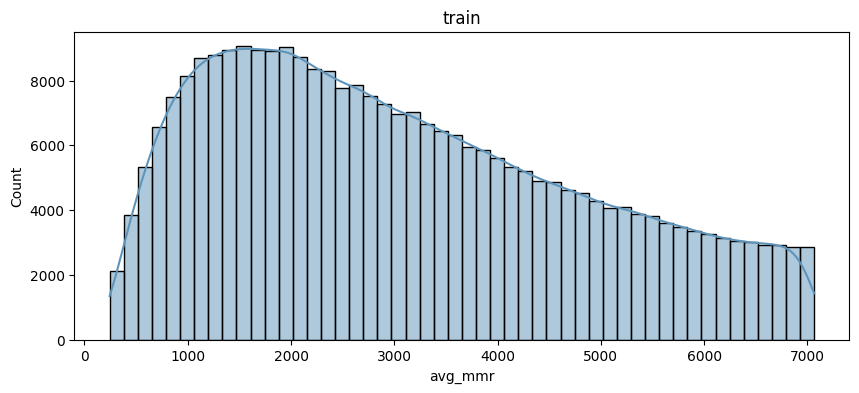

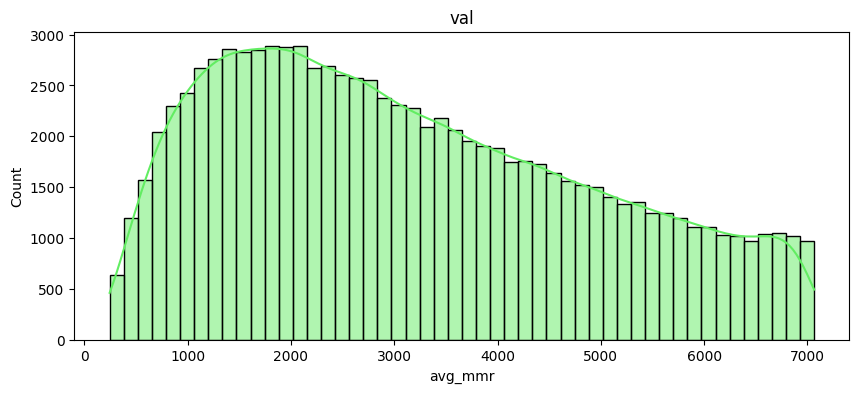

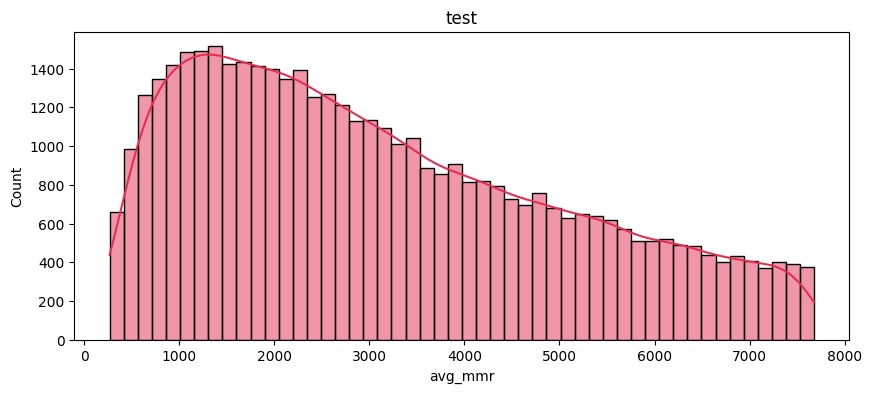

In [39]:
matches_df_train.head(3)

train_index, val_index = list(crossval.split(matches_df_train))[-2]
X_train = matches_df_train.iloc[train_index]
X_val = matches_df_train.iloc[val_index]

plt.figure(figsize=(10, 4))
sns.histplot(X_train['avg_mmr'], bins=50, kde=True, color="#5e94ba")
plt.title('train')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(X_val['avg_mmr'], bins=50, kde=True, color="#62ed62")
plt.title('val')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(matches_df_test['avg_mmr'], bins=50, kde=True, color="#e42f53")
plt.title('test')
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** Достаточно похоже на логарифмическое распределение по рисуночку также больше всго похоже на логнормальное распределение, мы его не проходили. если бы мы знали, что это такое, мы не знаем, что это такое

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

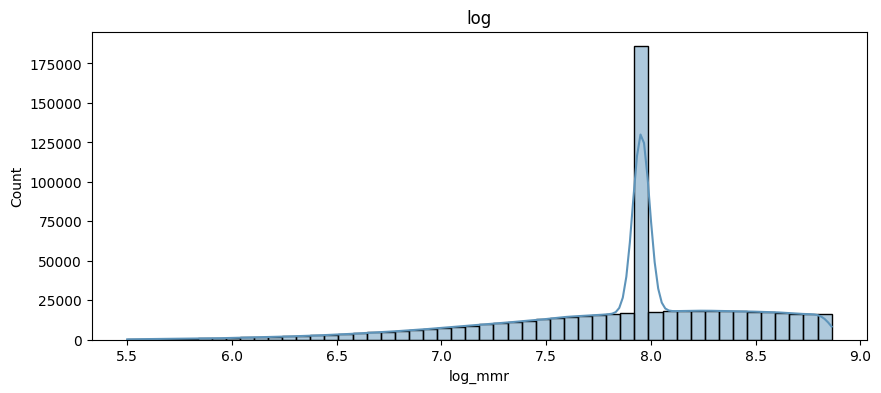

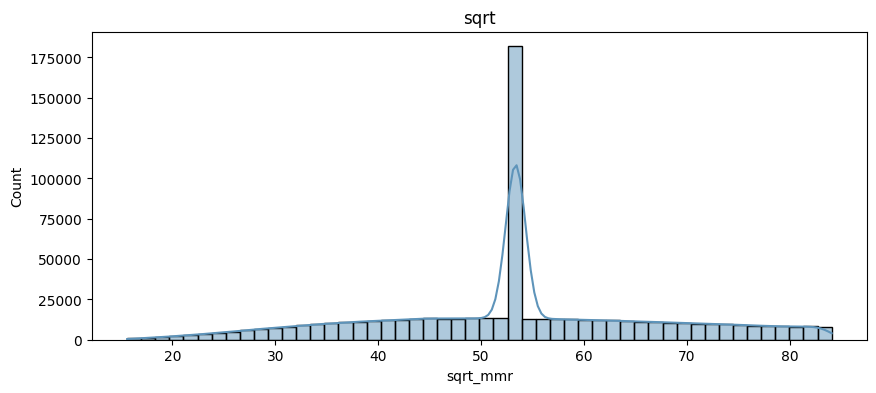

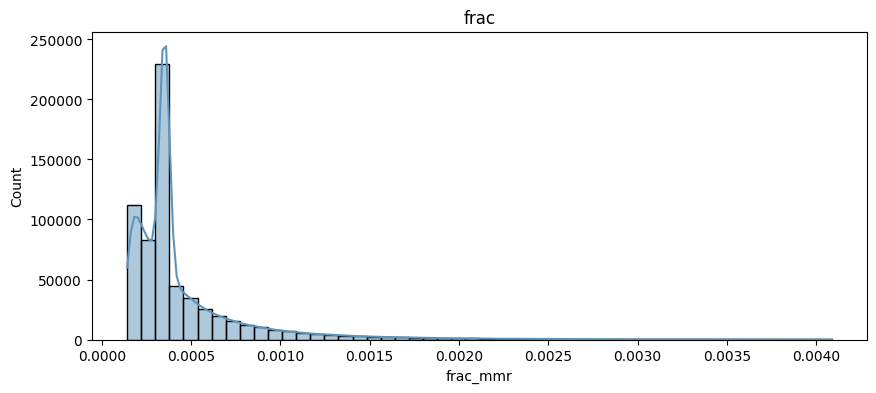

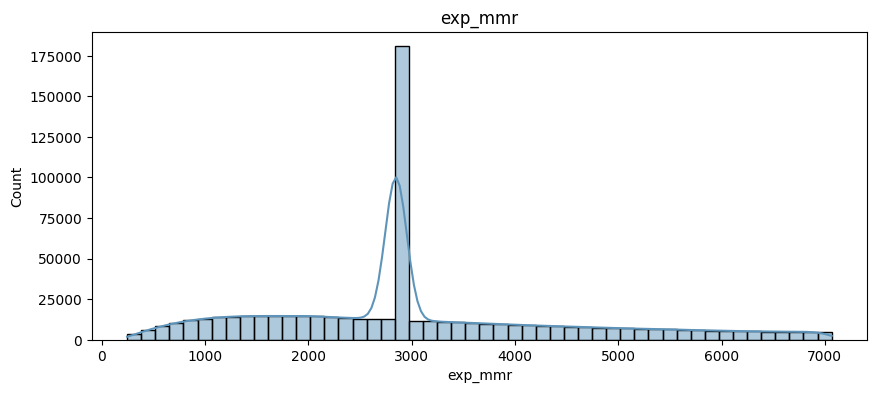

In [40]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import numpy as np

med = matches_df_train['avg_mmr'].median()
matches_df_train['avg_mmr'] = matches_df_train['avg_mmr'].fillna(med)
med = matches_df_test['avg_mmr'].median()
matches_df_test['avg_mmr'] = matches_df_test['avg_mmr'].fillna(med)

matches_df_train['log_mmr'] = np.log(matches_df_train['avg_mmr'] + 1)
matches_df_test['log_mmr'] = np.log(matches_df_test['avg_mmr'] + 1)
matches_df_train['sqrt_mmr'] = np.sqrt(matches_df_train['avg_mmr'])
matches_df_train['frac_mmr'] = 1 / (1 + matches_df_train['avg_mmr'])
matches_df_train['exp_mmr'] = np.exp(matches_df_train['log_mmr'])

plt.figure(figsize=(10, 4))
sns.histplot(matches_df_train['log_mmr'], bins=50, kde=True, color="#5e94ba")
plt.title('log')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(matches_df_train['sqrt_mmr'], bins=50, kde=True, color="#5e94ba")
plt.title('sqrt')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(matches_df_train['frac_mmr'], bins=50, kde=True, color="#5e94ba")
plt.title('frac')
plt.show()


plt.figure(figsize=(10, 4))
sns.histplot(matches_df_train['exp_mmr'], bins=50, kde=True, color="#5e94ba")
plt.title('exp_mmr')
plt.show()


Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Нет, пропуски нулями или средним заполнять не очень, потому что это может сильно отразиться на среднем и отклонении получается тоже, от этого может сместиться верхушечка распределения(экстремум аахвхвх). Лучше всего, чтобы не смещать, а заполнить пропуски медианой, это вроде как продвинутое решение ну и плюс к тому она устойчива к выбросам. 

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [41]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from sklearn.preprocessing import StandardScaler

X = pd.concat([X_reg, matches_df_train[['avg_mmr', 'game_mode']]], axis=1)
median_value = float(X['avg_mmr'].median())
X['mmr_missing'] = X['avg_mmr'].isna()
X['avg_mmr'] = X['avg_mmr'].fillna(median_value)
y = matches_df_train['radiant_win']
scores1 = []
cv = sklearn.model_selection.TimeSeriesSplit(n_splits=4)


for i, (train_index, val_index) in enumerate(cv.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    model = LogisticRegression(solver='liblinear', max_iter=1000)
    clf = model.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_val)[:, 1]
    scores1.append(gini(y_val, y_pred))
print(*scores1)


#я буду использовать первое преобразование
X = pd.concat([X_reg, matches_df_train[['log_mmr', 'game_mode']]], axis=1)
median_value = float(X['log_mmr'].median())
X['mmr_missing'] = X['log_mmr'].isna()
X['log_mmr'] = X['log_mmr'].fillna(median_value)
y = matches_df_train['radiant_win']
scores2 = []
for i, (train_index, val_index) in enumerate(cv.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    model = LogisticRegression(solver='liblinear', max_iter=1000)
    clf = model.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_val)[:, 1]
    scores2.append(gini(y_val, y_pred))
print(*scores2)




0.10423393263277192 0.10524575703413608 0.1053512892812345 0.10924800869040019
0.11756650792092449 0.11670513228919255 0.11750857692263761 0.11677353744338959


In [42]:
X = pd.concat([X_reg, matches_df_train[['sqrt_mmr', 'game_mode']]], axis=1)
median_value = float(X['sqrt_mmr'].median())
X['mmr_missing'] = X['sqrt_mmr'].isna()
X['sqrt_mmr'] = X['sqrt_mmr'].fillna(median_value)
y = matches_df_train['radiant_win']
scores2 = []
for i, (train_index, val_index) in enumerate(cv.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    model = LogisticRegression(solver='liblinear', max_iter=1000)
    clf = model.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_val)[:, 1]
    scores2.append(gini(y_val, y_pred))
print(*scores2)

0.11442869447334103 0.11385587504237393 0.11547469418635381 0.11358019123276564


В общем, тут хочется указать использование ЛЛМ. Промпт звучал так: бро, почему ничего не работает. Синий кит сказал мне, что нужно использовать liblinear. Как выяснилось позже, у нас данные немного разного масштаба, поэтому макс_итер ломался нещадно, а этот метод ЛогРега аодгоняет сам данные под нужный масштаб.

### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [43]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
player_df = pd.read_csv('player_df.csv')
constants_df = pd.read_csv('Constants.Heroes.csv')

In [44]:
player_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7650825 entries, 0 to 7650824
Data columns (total 14 columns):
 #   Column        Dtype  
---  ------        -----  
 0   player_slot   int64  
 1   account_id    int64  
 2   hero_id       int64  
 3   kills         float64
 4   deaths        float64
 5   assists       float64
 6   gold          float64
 7   last_hits     float64
 8   denies        float64
 9   gold_per_min  float64
 10  xp_per_min    float64
 11  hero_damage   float64
 12  tower_damage  float64
 13  match_id      int64  
dtypes: float64(10), int64(4)
memory usage: 817.2 MB


In [45]:
player_df[player_df['account_id'] < 0] #вот этот айди чета смущает

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
153,1,-1,44,15.0,14.0,6.0,1146.0,99.0,23.0,472.0,678.0,20610.0,258.0,519759
208,129,-1,99,2.0,6.0,0.0,441.0,32.0,0.0,230.0,249.0,3236.0,0.0,380288
266,0,-1,26,4.0,6.0,10.0,1668.0,20.0,8.0,251.0,387.0,7626.0,135.0,78412
468,130,-1,35,1.0,11.0,6.0,493.0,37.0,16.0,225.0,226.0,3405.0,0.0,139264
710,0,-1,32,19.0,1.0,9.0,1422.0,73.0,0.0,397.0,455.0,20446.0,240.0,483564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7649692,131,-1,37,1.0,5.0,4.0,515.0,44.0,21.0,243.0,306.0,3212.0,402.0,411972
7649905,129,-1,32,11.0,4.0,14.0,544.0,105.0,19.0,520.0,667.0,18080.0,650.0,258567
7650128,128,-1,30,9.0,13.0,5.0,271.0,13.0,9.0,258.0,216.0,11769.0,0.0,493065
7650410,129,-1,99,1.0,13.0,7.0,600.0,51.0,0.0,223.0,216.0,6096.0,49.0,484493


In [46]:
player_df[player_df['account_id'] > 1999999999] #тоже сомнительный какой-то огромный айди

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
10,128,4294967295,71,36.0,15.0,15.0,2742.0,76.0,4.0,538.0,645.0,34688.0,1177.0,251954
18,2,4294967295,65,2.0,10.0,9.0,277.0,98.0,1.0,326.0,386.0,6117.0,272.0,738147
20,128,4294967295,7,14.0,13.0,17.0,1846.0,251.0,0.0,361.0,474.0,22276.0,183.0,474296
25,128,4294967295,15,4.0,9.0,4.0,311.0,79.0,3.0,302.0,350.0,10442.0,88.0,242554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650816,4,4294967295,49,3.0,5.0,8.0,3003.0,56.0,0.0,375.0,294.0,6399.0,2000.0,585273
7650818,131,4294967295,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,196312
7650819,4,4294967295,95,12.0,11.0,9.0,1679.0,349.0,33.0,520.0,483.0,20825.0,2969.0,226515
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** В данном случае не представляется такой возможности, такие матчи составляют огромную часть выборки, ущерб данным определенно будет, можно заметить6 что по некоторым матчам есть наны, их смело можно выкидывать, однако если совсем все выкинуть будет большое смещение среднего.

</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [47]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
unique_heroes = player_df.groupby(['match_id', 'hero_id']).size().reset_index(name='count')
suspect = unique_heroes[unique_heroes['count'] > 1]['match_id']
player_df = player_df[~player_df['match_id'].isin(suspect)]
player_df

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7650820,4,4294967295,63,16.0,9.0,10.0,467.0,152.0,5.0,494.0,619.0,24378.0,1700.0,400075
7650821,0,4294967295,95,8.0,11.0,13.0,9.0,183.0,4.0,449.0,544.0,13792.0,4817.0,465077
7650822,3,122912707,36,6.0,3.0,18.0,1078.0,74.0,8.0,334.0,336.0,7769.0,533.0,571444
7650823,0,104518723,87,4.0,11.0,9.0,1017.0,18.0,4.0,219.0,218.0,4087.0,91.0,234954


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [48]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
zerohero = player_df[player_df['hero_id'] == 0]['match_id']
player_df = player_df[~player_df['match_id'].isin(zerohero)]
player_df = player_df.dropna()

suspect_id = [-1, 4294967295]
player_df['team'] = 'a'
player_df.loc[player_df['player_slot'].isin([0,1,2,3,4]), 'team'] = 'radiant'
player_df.loc[player_df['player_slot'].isin([128,129,130,131,132]), 'team'] = 'dire'
clean = player_df[~player_df['account_id'].isin(suspect_id)]
clean = clean.groupby(['match_id', 'account_id'])['team'].nunique()
clean = clean[clean > 1].reset_index()
player_df = player_df[~player_df['match_id'].isin(clean['match_id'])]

matchid = np.concatenate([matches_df_train['match_id'].unique(), matches_df_test['match_id'].unique()])
player_df = player_df[player_df['match_id'].isin(matchid)]
player_df

temp = player_df.groupby(['match_id', 'team']).size().reset_index(name='count')
ans = temp[temp['count'] != 5].any()
ans

match_id    False
team        False
count       False
dtype: bool

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [49]:
matches_df_train = matches_df_train.drop('sqrt_mmr', axis=1)
matches_df_train = matches_df_train.drop('exp_mmr', axis=1)
matches_df_train = matches_df_train.drop('frac_mmr', axis=1)
matches_df_train = matches_df_train.drop('day', axis=1)
matches_df_train = matches_df_train.drop('dayofweek', axis=1)
matches_df_train = matches_df_train.drop('month', axis=1)
matches_df_train.head(5)

,match_id,date,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,region_Australia,game_mode,radiant_win,avg_mmr,summer,log_mmr
147802,176828,2024-01-01,1,0,0,0,0,0,0,0,0,0,22,True,2846.85,False,7.954320
442520,529827,2024-01-01,0,0,0,1,0,0,0,0,0,0,1,False,4391.50,False,8.387654
274960,329224,2024-01-01,1,0,0,0,0,0,0,0,0,0,1,True,2846.85,False,7.954320
415926,497876,2024-01-01,0,0,0,1,0,0,0,0,0,0,1,False,2846.85,False,7.954320
451726,540899,2024-01-01,0,0,1,0,0,0,0,0,0,0,1,True,5158.50,False,8.548595


In [50]:
matches_df_test = matches_df_test.drop('day', axis=1)
matches_df_test = matches_df_test.drop('dayofweek', axis=1)
matches_df_test = matches_df_test.drop('month', axis=1)
matches_df_test.head(5)

,match_id,date,region_China,region_Europe West,region_Australia,region_SE Asia,region_Middle East,region_US East,region_South Africa,region_South America,region_Europe East,region_US West,game_mode,avg_mmr,summer,log_mmr
0,8,2024-12-01,1,0,0,0,0,0,0,0,0,0,1,2305.00,False,7.743270
1,29,2024-12-17,0,1,0,0,0,0,0,0,0,0,22,2778.75,False,7.930116
2,34,2024-12-19,0,1,0,0,0,0,0,0,0,0,22,2278.50,False,7.731711
3,36,2024-12-19,0,1,0,0,0,0,0,0,0,0,1,305.80,False,5.726196
4,61,2024-12-06,0,0,1,0,0,0,0,0,0,0,1,5142.40,False,8.545470


In [51]:
from scipy.sparse import csr_array  # вам может понравиться

class HeroesEncoder:

    def fit(self, X, y=None):
        self.hero_ids = np.sort(X['hero_id'].unique())
        self.hero_idx = {hero: i for i, hero in enumerate(self.hero_ids)}
        

    def transform(self, X, y=None):
        df = X.copy()
        df['team'] = np.where(df['player_slot'] <= 4, 1, -1)

        matches, row = np.unique(df['match_id'], return_inverse=True)
        heroes = np.array([self.hero_idx.get(h, -1) for h in df['hero_id']])
        data = df['team'].values

        df_sparse = pd.DataFrame.sparse.from_spmatrix(
            csr_array((data, (row, heroes)), shape=(len(matches), len(self.hero_ids))),
            index=matches,
            columns=[f'hero_{h}' for h in self.hero_ids]
        )
        df_sparse.index.name = 'match_id'
        return df_sparse.reset_index()


Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [52]:
encoder = HeroesEncoder()
encoder.fit(player_df)
hero_train = encoder.transform(player_df[player_df['match_id'].isin(matches_df_train['match_id'])])
hero_test = encoder.transform(player_df[player_df['match_id'].isin(matches_df_test['match_id'])])
matches_df_train_bes_hero, matches_df_test_bes_hero = matches_df_train.copy(), matches_df_test.copy()
matches_df_train = matches_df_train.merge(hero_train, on='match_id', how='left').fillna(0) # у нас появляются пропуски на месте тех героев, что не принимали участия в игре
matches_df_test = matches_df_test.merge(hero_test, on='match_id', how='left').fillna(0)

In [53]:
cv_1, cv_2 = sklearn.model_selection.TimeSeriesSplit(n_splits=4), sklearn.model_selection.TimeSeriesSplit(n_splits=4)
score_hero, score_bes = [], []
X, y = matches_df_train.sort_values('date').drop(['radiant_win', 'date', 'avg_mmr', 'match_id'], axis=1), matches_df_train.sort_values('date')['radiant_win']

for i, (train_index, val_index) in enumerate(cv_1.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model_hero = LogisticRegression(max_iter=1000, solver='liblinear')

    model_hero.fit(X_train, y_train)
    y_pred = model_hero.predict_proba(X_val)[:, 1]

    score_hero.append(gini(y_val, y_pred))
print(*score_hero)
print(np.mean(score_hero))

X, y = matches_df_train_bes_hero.sort_values('date').drop(['radiant_win', 'date', 'avg_mmr', 'match_id'], axis=1), matches_df_train_bes_hero.sort_values('date')['radiant_win']

for i, (train_index, val_index) in enumerate(cv_2.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model_bes = LogisticRegression(max_iter=1000, solver='liblinear')

    model_bes.fit(X_train, y_train)
    y_pred = model_bes.predict_proba(X_val)[:, 1]

    score_bes.append(gini(y_val, y_pred))
print(*score_bes)
print(np.mean(score_bes))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python

0.29402729391460736 0.2962340330386628 0.29175024207146816 0.29367299298027283
0.2939211405012528
0.11700217596386842 0.11679501645712786 0.11787385858488286 0.1165673092004278
0.11705959005157673


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

Почти весь код был взят отсюда:

https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/001_first.html

и отюда:

https://habr.com/ru/articles/704432/ (это типа перевода доки ахах)

https://habr.com/ru/companies/skillfactory/articles/900658/

In [54]:
import optuna


X_to_opt, y_to_opt = matches_df_train.sort_values('date').drop(['radiant_win', 'date', 'avg_mmr', 'match_id'], axis=1), matches_df_train.sort_values('date')['radiant_win']

def objective(trial):
    # model parameters
    params = {
        'penalty': trial.suggest_categorical('penalty', ['l2', 'l1']),
        'C': trial.suggest_float('C', 0.01, 10.0, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
    }

    # fit
    model = LogisticRegression(**params, max_iter=500)
    model.fit(X_to_opt, y_to_opt)

    # predict
    gini_valid = gini(y_to_opt, model.predict_proba(X_to_opt)[:, 1])
    
    return gini_valid


study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-16 22:21:17,348] A new study created in memory with name: no-name-6fc9c903-7b0f-49a3-877f-b20a45b28342


  0%|          | 0/25 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[I 2026-03-16 22:23:10,807] Trial 0 finished with value: 0.2981843285768826 and parameters: {'penalty': 'l1', 'C': 1.0857944868386213, 'solver': 'saga'}. Best is trial 0 with value: 0.2981843285768826.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


...

[I 2026-03-16 22:39:33,755] Trial 22 finished with value: 0.29818533697594796 and parameters: {'penalty': 'l2', 'C': 0.05164662208632976, 'solver': 'liblinear'}. Best is trial 21 with value: 0.29818628819955384.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[I 2026-03-16 22:39:36,235] Trial 23 finished with value: 0.29818517061016037 and parameters: {'penalty': 'l2', 'C': 0.3710850734915323, 'solver': 'liblinear'}. Best is trial 21 with value: 0.29818628819955384.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[I 2026-03-16 22:39:38,613] Trial 24 finished with value: 0.29811633797777515 and parameters: {'penalty': 'l2', 'C': 0.010850967872329422, 'solver': 'liblinear'}. Best is trial 21 with value: 0.29818628819955384.


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

In [55]:
optuna.visualization.plot_param_importances(study)

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** из графика видно, что важнее всего параметр С, причем с очень солидным отрывом. Наименьшее влияние имеет penalty

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [70]:
import pickle


top_params = study.best_params
print(top_params)

model = LogisticRegression(**top_params, max_iter=1000)
model.fit(X_to_opt, y_to_opt)

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

X = matches_df_test.sort_values('date').drop(['date', 'match_id', 'avg_mmr'], axis=1)[X_to_opt.columns.to_list()]
submission = model.predict_proba(X)[:, 1]
submission_df = pd.DataFrame({'ID': matches_df_test.sort_values('date')['match_id'],
                              'Value': submission})
submission_df.to_csv('submission.csv', index=False)

{'penalty': 'l2', 'C': 0.07527749530760935, 'solver': 'liblinear'}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

